In [1]:
# LECTURE 10 CODE: RANDOMNESS AND MONTE CARLO

In [7]:
import numpy.random as rng
import numpy as np 

a = np.arange(0,10,1)

b = rng = rng.default_rng(seed=1234) #creates an instance of the generator
c = rng.random(size=2) #Returns 2 random floats f, where 0 <= f < 1
d = rng.integers(low=0,high=10,size=5) #Returns 5 integers between 0 and 10
e = rng.choice(a) #returns a random choice from the array a

print(a)
print(b)
print(c)
print(d)
print(e)


[0 1 2 3 4 5 6 7 8 9]
Generator(PCG64)
[0.97669977 0.38019574]
[1 9 1 2 1]
3


(2000,) (2000,) (2000,)
0.1802263841376992 0.004742813061716755


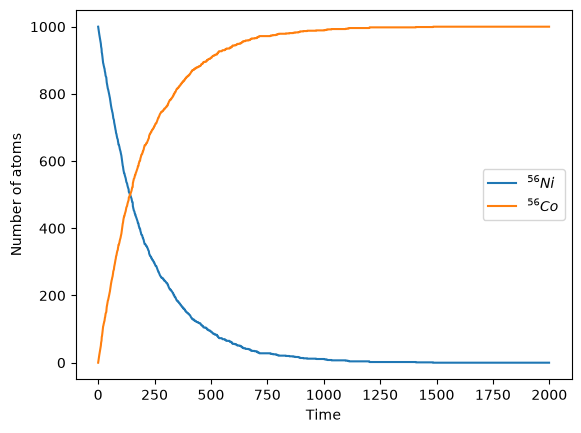

In [12]:
# Radioactive Decay:

import numpy as np
import matplotlib.pyplot as plt

# Constants
N_Ni = 1000 # Number of nickel atoms
N_Co = 0 # Number of Cobalt atoms
tau = 6.075*24 # Half life of nickel in hours
h = 1.0 # Size of time-step in hours
p = 1 - 2**(-h/tau) # Probability of decay in one step
tmax = 2000 # Total time

# Lists of plot points
tpoints = np.arange(0.0,tmax,h)
Nt = int(tmax//h)
Nipoints = np.zeros(Nt)
Copoints = np.zeros(Nt)
print(tpoints.shape,Nipoints.shape,Copoints.shape)

#initialize random number generator
rng = np.random.default_rng()
print(rng.random(),p)
# Main loop
for i in range(Nt):
    Nipoints[i] = N_Ni
    Copoints[i] = N_Co
    
 # Calculate the number of atoms that decay
    decay = 0
    for i in range(N_Ni):
        if rng.random() < p:
            decay += 1
    N_Ni -= decay
    N_Co += decay
    
# Make the graph
plt.plot(tpoints,Nipoints,label='$^{56}Ni$')
plt.plot(tpoints,Copoints,label='$^{56}Co$')
plt.xlabel("Time")
plt.ylabel("Number of atoms")
plt.legend()
plt.show()

(2000,) (2000,) (2000,) (2000,)
0.0897685161805305 0.004742813061716755


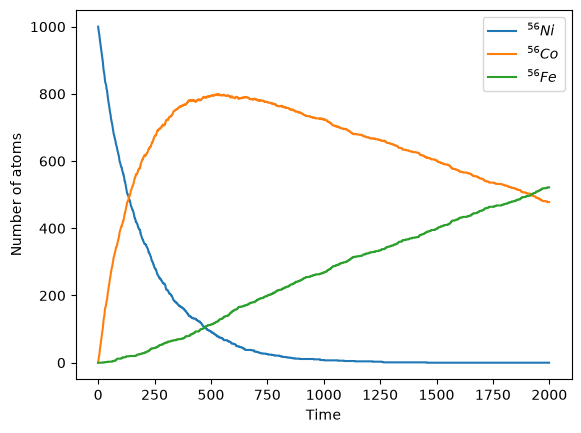

0


In [24]:
# Radioactive Decay:

import numpy as np
import matplotlib.pyplot as plt

# Constants
N_Ni = 1000 # Number of nickel atoms
N_Co = 0 # Number of Cobalt atoms
N_Fe = 0
tau_Ni = 6.075*24 # Half life of nickel in hours
tau_Co = 77.24 * 24
h = 1.0 # Size of time-step in hours
p_Ni = 1 - 2**(-h/tau_Ni) # Probability of decay in one step
p_Co = 1 - 2**(-h/tau_Co)
tmax = 2000 # Total time

# Lists of plot points
tpoints = np.arange(0.0,tmax,h)
Nt = int(tmax//h)
Nipoints = np.zeros(Nt)
Copoints = np.zeros(Nt)
Fepoints = np.zeros(Nt)
print(tpoints.shape,Nipoints.shape,Copoints.shape, Fepoints.shape)

#initialize random number generator
rng = np.random.default_rng()
print(rng.random(),p_Ni)

# Main loop
for i in range(Nt):
    # Record current counts
    Nipoints[i] = N_Ni
    Copoints[i] = N_Co
    Fepoints[i] = N_Fe

    # 1. Calculate Cobalt decays FIRST (using existing N_Co)
    decay_Co = 0
    for j in range(N_Co):
        if rng.random() < p_Co:
            decay_Co += 1

    # 2. Calculate Nickel decays SECOND
    decay_Ni = 0
    for j in range(N_Ni):
        if rng.random() < p_Ni:
            decay_Ni += 1

    # 3. Update atom counts after evaluating both probabilities
    N_Ni -= decay_Ni
    N_Co += decay_Ni - decay_Co
    N_Fe += decay_Co
    
# Make the graph
plt.plot(tpoints,Nipoints,label='$^{56}Ni$')
plt.plot(tpoints,Copoints,label='$^{56}Co$')
plt.plot(tpoints, Fepoints, label='$^{56}Fe$')
plt.xlabel("Time")
plt.ylabel("Number of atoms")
plt.legend()
plt.show()

rng = np.random.default_rng()

# Generate N_Ni random numbers in [0.0, 1.0) and count how many decay
decay_test = (rng.random(size=N_Ni) < p_Ni).sum()

print(decay_test)

# try to improve code by removing for loop and using np arrays: 
# decay = (rng.random(size(N_Ni) < p).sum()

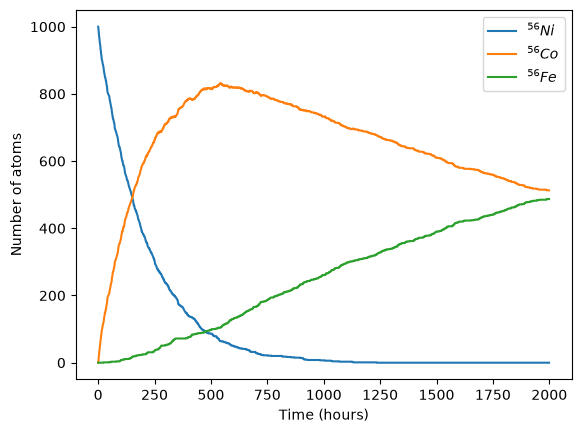

In [25]:
# Same Code as above but use NP Vectors not for loops: 

import numpy as np
import matplotlib.pyplot as plt

# Constants
N_Ni = 1000 # start with 1000 atoms of Nickel
N_Co = 0
N_Fe = 0
tau_Ni = 6.075 * 24 # Nickel decay rate
tau_Co = 77.24 * 24 # Cobalt decay rate
h = 1.0             # steps
p_Ni = 1 - 2**(-h / tau_Ni)
p_Co = 1 - 2**(-h / tau_Co)
tmax = 2000 # max timesteps

tpoints = np.arange(0.0, tmax, h) # time plot points
Nt = len(tpoints) # Number of time plot points

# initializing arrays the length of the number of time steps
Nipoints = np.zeros(Nt) 
Copoints = np.zeros(Nt)
Fepoints = np.zeros(Nt)

# random number generator
rng = np.random.default_rng()

# Main loop, iterate once for every timestep
for i in range(Nt):
    Nipoints[i] = N_Ni
    Copoints[i] = N_Co
    Fepoints[i] = N_Fe

    # Vectorized decay calculations
    decay_Co = (rng.random(size=N_Co) < p_Co).sum()
    decay_Ni = (rng.random(size=N_Ni) < p_Ni).sum()

    # Update atom counts
    N_Ni -= decay_Ni
    N_Co += decay_Ni - decay_Co
    N_Fe += decay_Co

# Plotting
plt.plot(tpoints, Nipoints, label='$^{56}Ni$')
plt.plot(tpoints, Copoints, label='$^{56}Co$')
plt.plot(tpoints, Fepoints, label='$^{56}Fe$')
plt.xlabel("Time (hours)")
plt.ylabel("Number of atoms")
plt.legend()
plt.show()

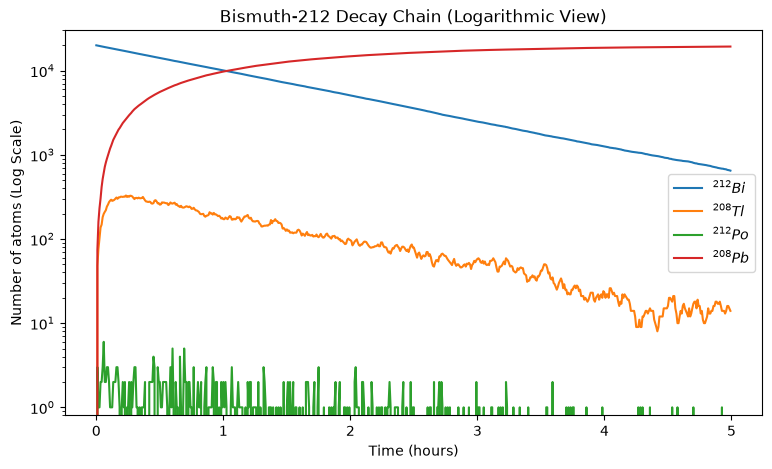

In [35]:
# Exercise 2: More Radioactive Decay

import numpy as np
import matplotlib.pyplot as plt

# Constants
N_Bi = 20000
N_Po = 0
N_Tl = 0
N_Pb = 0

tau_Bi = 60.55 / 60              # decay half-life in hours
tau_Po = 0.299 * 2.77778e-10     # decay half-life in hours
tau_Tl = 3.053 / 60              # decay half-life in hours

# Time-step and maximum time (MUST be defined before calculating p)
h = 1.0 / 3600.0                 # 1 second in hours
tmax = 5.0                       # 5 hours total

# Probabilities per step h
p_Bi = 1 - 2**(-h / tau_Bi)
p_Po = 1 - 2**(-h / tau_Po)
p_Tl = 1 - 2**(-h / tau_Tl)

p_Bi_to_Po = p_Bi * 0.6406       # Bi -> Po branch
p_Bi_to_Tl = p_Bi * 0.3594       # Bi -> Tl branch
p_Bi_stay  = 1 - p_Bi

tpoints = np.arange(0.0, tmax, h)
Nt = len(tpoints)

Bipoints = np.zeros(Nt)
Popoints = np.zeros(Nt)
Tlpoints = np.zeros(Nt)
Pbpoints = np.zeros(Nt)

rng = np.random.default_rng()

# Main loop
for i in range(Nt):
    Bipoints[i] = N_Bi
    Popoints[i] = N_Po
    Tlpoints[i] = N_Tl
    Pbpoints[i] = N_Pb

    # Vectorized decay calculations
    r_Bi = rng.random(size=N_Bi)
    decay_Bi_to_Po = (r_Bi < p_Bi_to_Po).sum()
    decay_Bi_to_Tl = ((r_Bi >= p_Bi_to_Po) & (r_Bi < p_Bi)).sum()

    decay_Po_to_Pb = (rng.random(size=N_Po) < p_Po).sum()
    decay_Tl_to_Pb = (rng.random(size=N_Tl) < p_Tl).sum()

    # Update atom counts
    N_Bi -= (decay_Bi_to_Po + decay_Bi_to_Tl)
    N_Tl += decay_Bi_to_Tl - decay_Tl_to_Pb
    N_Po += decay_Bi_to_Po - decay_Po_to_Pb
    N_Pb += decay_Tl_to_Pb + decay_Po_to_Pb

# Plotting
# Add log scale to see the tiny population curves clearly
plt.figure(figsize=(9, 5))

# Downsample to plot every 30th point (every 30 seconds)
step = 30
plt.plot(tpoints[::step], Bipoints[::step], label='$^{212}Bi$')
plt.plot(tpoints[::step], Tlpoints[::step], label='$^{208}Tl$')
plt.plot(tpoints[::step], Popoints[::step], label='$^{212}Po$')
plt.plot(tpoints[::step], Pbpoints[::step], label='$^{208}Pb$')

plt.yscale('log')  # Makes low populations (1 to 200) visible alongside 10,000
plt.ylim(0.8, 30000)
plt.xlabel("Time (hours)")
plt.ylabel("Number of atoms (Log Scale)")
plt.title("Bismuth-212 Decay Chain (Logarithmic View)")
plt.legend()
plt.show()

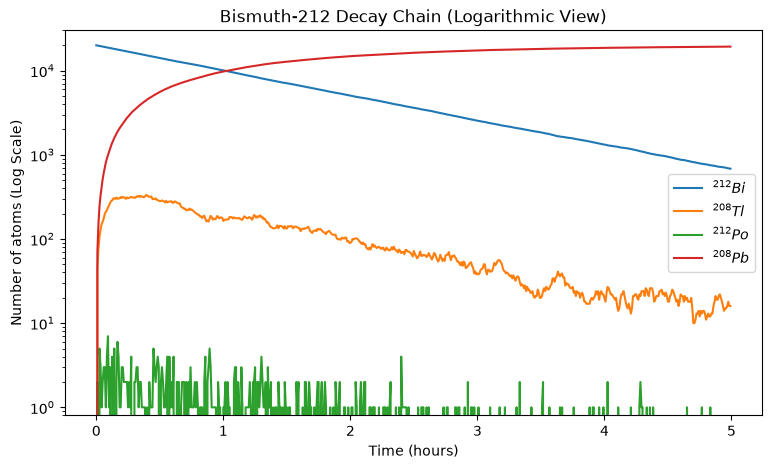

In [36]:
# Improvements to the above code: We use Binomial Theorem

# Exercise 2: More Radioactive Decay

import numpy as np
import matplotlib.pyplot as plt

# Constants
N_Bi = 20000
N_Po = 0
N_Tl = 0
N_Pb = 0

tau_Bi = 60.55 / 60              # decay half-life in hours
tau_Po = 0.299 * 2.77778e-10     # decay half-life in hours
tau_Tl = 3.053 / 60              # decay half-life in hours

# Time-step and maximum time (MUST be defined before calculating p)
h = 1.0 / 3600.0                 # 1 second in hours
tmax = 5.0                       # 5 hours total

# Probabilities per step h
p_Bi = 1 - 2**(-h / tau_Bi)
p_Po = 1 - 2**(-h / tau_Po)
p_Tl = 1 - 2**(-h / tau_Tl)

p_Bi_to_Po = p_Bi * 0.6406       # Bi -> Po branch
p_Bi_to_Tl = p_Bi * 0.3594       # Bi -> Tl branch
p_Bi_stay  = 1 - p_Bi

tpoints = np.arange(0.0, tmax, h)
Nt = len(tpoints)

Bipoints = np.zeros(Nt)
Popoints = np.zeros(Nt)
Tlpoints = np.zeros(Nt)
Pbpoints = np.zeros(Nt)

rng = np.random.default_rng()

# Main loop
for i in range(Nt):
    Bipoints[i] = N_Bi
    Popoints[i] = N_Po
    Tlpoints[i] = N_Tl
    Pbpoints[i] = N_Pb

    # Vectorized decay calculations
        # --- Bismuth Branching (2 Binomial steps) ---
    
    # 1. Total Bismuth decays in this time step
    total_decay_Bi = rng.binomial(n=N_Bi, p=p_Bi)
    
    # 2. Of those decaying Bi atoms, how many go to Polonium (64.06% branch)
    decay_Bi_to_Po = rng.binomial(n=total_decay_Bi, p=0.6406)
    decay_Bi_to_Tl = total_decay_Bi - decay_Bi_to_Po
    
    # --- Daughter Decays ---
    decay_Po_to_Pb = rng.binomial(n=N_Po, p=p_Po)
    decay_Tl_to_Pb = rng.binomial(n=N_Tl, p=p_Tl)
    
    # --- State Updates ---
    N_Bi -= total_decay_Bi
    N_Po += decay_Bi_to_Po - decay_Po_to_Pb
    N_Tl += decay_Bi_to_Tl - decay_Tl_to_Pb
    N_Pb += decay_Po_to_Pb + decay_Tl_to_Pb

# Plotting
# Add log scale to see the tiny population curves clearly
plt.figure(figsize=(9, 5))

# Downsample to plot every 30th point (every 30 seconds)
step = 30
plt.plot(tpoints[::step], Bipoints[::step], label='$^{212}Bi$')
plt.plot(tpoints[::step], Tlpoints[::step], label='$^{208}Tl$')
plt.plot(tpoints[::step], Popoints[::step], label='$^{212}Po$')
plt.plot(tpoints[::step], Pbpoints[::step], label='$^{208}Pb$')

plt.yscale('log')  # Makes low populations (1 to 200) visible alongside 10,000
plt.ylim(0.8, 30000)
plt.xlabel("Time (hours)")
plt.ylabel("Number of atoms (Log Scale)")
plt.title("Bismuth-212 Decay Chain (Logarithmic View)")
plt.legend()
plt.show()